In [79]:
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print(" Bankruptcy Prediction Model (Balanced Version)")

 Bankruptcy Prediction Model (Balanced Version)


In [80]:
# 1. LOAD DATA

data = arff.loadarff("1year.arff")
df = pd.DataFrame(data[0])

In [81]:
df.head(5)

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,b'0'
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,b'0'
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,b'0'
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,b'0'
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,b'0'


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7027 entries, 0 to 7026
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   7024 non-null   float64
 1   Attr2   7024 non-null   float64
 2   Attr3   7024 non-null   float64
 3   Attr4   6997 non-null   float64
 4   Attr5   7019 non-null   float64
 5   Attr6   7024 non-null   float64
 6   Attr7   7024 non-null   float64
 7   Attr8   7002 non-null   float64
 8   Attr9   7026 non-null   float64
 9   Attr10  7024 non-null   float64
 10  Attr11  6988 non-null   float64
 11  Attr12  6997 non-null   float64
 12  Attr13  7027 non-null   float64
 13  Attr14  7024 non-null   float64
 14  Attr15  7025 non-null   float64
 15  Attr16  7002 non-null   float64
 16  Attr17  7002 non-null   float64
 17  Attr18  7024 non-null   float64
 18  Attr19  7027 non-null   float64
 19  Attr20  7027 non-null   float64
 20  Attr21  5405 non-null   float64
 21  Attr22  7024 non-null   float64
 22  

In [83]:
corr = df.corr()

pd.set_option('display.max_rows', None)

print(corr["class"].sort_values(ascending=False))

class     1.000000
Attr2     0.065150
Attr51    0.064746
Attr32    0.050432
Attr52    0.034025
Attr34    0.027680
Attr50    0.021969
Attr33    0.013934
Attr40    0.010320
Attr15    0.008643
Attr4     0.008071
Attr46    0.005647
Attr63    0.004930
Attr45    0.002699
Attr49    0.002517
Attr56    0.002390
Attr59    0.002221
Attr8    -0.000151
Attr17   -0.000184
Attr42   -0.001840
Attr39   -0.001853
Attr5    -0.002013
Attr58   -0.002389
Attr30   -0.002392
Attr20   -0.002395
Attr43   -0.002470
Attr60   -0.002482
Attr44   -0.002495
Attr61   -0.002534
Attr62   -0.002679
Attr13   -0.002862
Attr48   -0.003164
Attr21   -0.003892
Attr37   -0.003910
Attr23   -0.004350
Attr31   -0.004414
Attr19   -0.004445
Attr27   -0.004650
Attr22   -0.005379
Attr41   -0.006035
Attr11   -0.006282
Attr35   -0.006580
Attr36   -0.006870
Attr47   -0.006870
Attr54   -0.006978
Attr53   -0.006980
Attr9    -0.007061
Attr64   -0.007198
Attr26   -0.010477
Attr1    -0.010643
Attr24   -0.010807
Attr7    -0.012167
Attr14   -0.

In [84]:
# Select important financial ratios
important_features = ["Attr1","Attr2","Attr3","Attr4","Attr7","Attr9","Attr10","Attr12",
                     "Attr18","Attr22","Attr23","Attr27","Attr31","Attr33","Attr60","class"]

#DESCRIPTION(SOURCE OF ATTR 1-ATTR 64 MEANING)

The features in the dataset are labeled as Attr1 to Attr64, which are anonymized attribute names. The actual meanings of these attributes were obtained from the original dataset documentation provided by the data source.

Specifically, the dataset used in this project is derived from a publicly available financial dataset in ARFF format (commonly available on platforms such as the UCI Machine Learning Repository). The detailed descriptions of each attribute (Attr1–Attr64) are provided in the dataset’s “Attribute Information” section.

These descriptions define each attribute as a specific financial ratio, such as profitability, liquidity, leverage, and efficiency measures. The interpretation of features in this project is based on that official documentation.

In [86]:
# RENAME FEATURES

df = df[important_features].rename(columns={
    "Attr1": "ROA",
    "Attr2": "Leverage",
    "Attr3": "Working_Capital",
    "Attr4": "Liquidity",
    "Attr7": "EBIT",
    "Attr9": "Asset_Turnover",
    "Attr10": "Equity_Ratio",
    "Attr12": "Gross_Profit_Liabilities",
    "Attr18": "Net_Profit_Margin",
    "Attr22": "Operating_ROA",
    "Attr23": "Net_Profit_Liabilities",
    "Attr27": "Operating_Profit",
    "Attr31": "Gross_Profit_Margin",
    "Attr33": "Operating_Expense",
    "Attr60": "Inventory_Turnover",
    "class": "target"
})

In [87]:
df.head(5)

,ROA,Leverage,Working_Capital,Liquidity,EBIT,Asset_Turnover,Equity_Ratio,Gross_Profit_Liabilities,Net_Profit_Margin,Operating_ROA,Net_Profit_Liabilities,Operating_Profit,Gross_Profit_Margin,Operating_Expense,Inventory_Turnover,target
0,0.200550,0.37951,0.39641,2.0472,0.249760,1.1389,0.50494,0.65980,0.249760,0.21402,0.119980,1.45820,0.149420,3.8772,8.4160,b'0'
1,0.209120,0.49988,0.47225,1.9447,0.258340,1.6996,0.49788,0.51680,0.258340,0.24806,0.123040,88.44400,0.152000,2.9876,4.1486,b'0'
2,0.248660,0.69592,0.26713,1.5548,0.309060,1.3090,0.30408,0.64184,0.309060,0.30260,0.189960,86.01100,0.238150,2.0630,4.9909,b'0'
3,0.081483,0.30734,0.45879,2.4928,0.092704,1.0571,0.57353,0.30163,0.092704,0.11550,0.062782,0.94076,0.071428,3.9948,4.5746,b'0'
4,0.187320,0.61323,0.22960,1.4063,0.187320,1.1559,0.38677,0.33147,0.187320,0.19832,0.115530,1.41380,0.115530,2.4823,6.3985,b'0'


In [88]:
# 3. CLEANING

df["target"] = df["target"].str.decode("utf-8").astype(int)
df = df.fillna(df.mean())

X = df.drop("target", axis=1)
y = df["target"]

print("Class Distribution:\n", y.value_counts())

Class Distribution:
 target
0    6756
1     271
Name: count, dtype: int64


In [89]:
# 4. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [90]:
# 5. SMOTE (BALANCE DATA)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train).value_counts())

After SMOTE:
 target
0    5404
1    5404
Name: count, dtype: int64


In [91]:
# 6. FEATURE SELECTION (TOP 12)

base_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

base_model.fit(X_train, y_train)

selector = SelectFromModel(base_model, max_features=12, prefit=True)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]

print("\n✅ Selected Top 12 Features:")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")


✅ Selected Top 12 Features:
1. ROA
2. Leverage
3. Asset_Turnover
4. Gross_Profit_Liabilities
5. Operating_Profit


In [92]:
# 7. ENSEMBLE MODEL

model1 = XGBClassifier(n_estimators=120, max_depth=3, learning_rate=0.05, random_state=42)
model2 = XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.03, random_state=43)
model3 = XGBClassifier(n_estimators=130, max_depth=2, learning_rate=0.04, random_state=44)

ensemble = VotingClassifier([
    ('m1', model1),
    ('m2', model2),
    ('m3', model3)
], voting='soft')

ensemble.fit(X_train_sel, y_train)

VotingClassifier(estimators=[('m1',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constrai...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.04, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=2,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=130, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [93]:
# 8. THRESHOLD OPTIMIZATION

y_prob = ensemble.predict_proba(X_test_sel)[:, 1]

prec, rec, thresh = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)

BEST_THRESHOLD = thresh[best_idx]

print("\nBest Threshold:", BEST_THRESHOLD)

y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

print("Prediction distribution:", np.bincount(y_pred))


Best Threshold: 0.83717704
Prediction distribution: [1368   38]


In [94]:
# 9. EVALUATION

print("\n📊 MODEL PERFORMANCE")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

roc_auc = roc_auc_score(y_test, y_prob)


📊 MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1352
           1       0.74      0.52      0.61        54

    accuracy                           0.97      1406
   macro avg       0.86      0.76      0.80      1406
weighted avg       0.97      0.97      0.97      1406

Confusion Matrix:
 [[1342   10]
 [  26   28]]


Text(0.5, 1.0, 'Confusion Matrix')

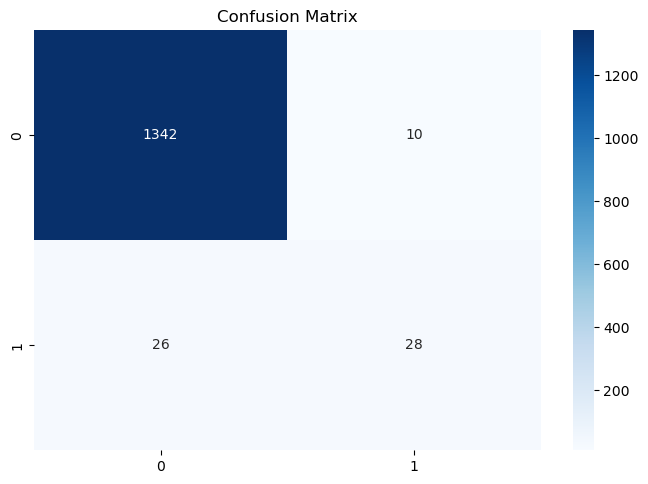

In [95]:
# 10. VISUALIZATIOn
plt.figure(figsize=(18, 12))

# Confusion Matrix
plt.subplot(2,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")

Text(0.5, 1.0, 'ROC Curve')

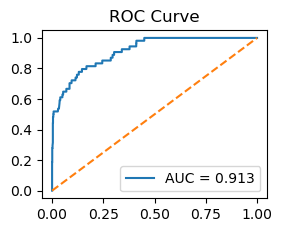

In [96]:
# ROC Curve
plt.subplot(2,2,2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")

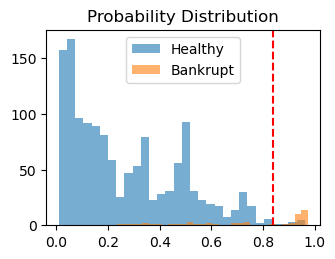

In [97]:
# Probability Distribution
plt.subplot(2,2,3)
plt.hist(y_prob[y_test==0], bins=30, alpha=0.6, label="Healthy")
plt.hist(y_prob[y_test==1], bins=30, alpha=0.6, label="Bankrupt")
plt.axvline(BEST_THRESHOLD, color='red', linestyle='--')
plt.legend()
plt.title("Probability Distribution")

plt.tight_layout()
plt.show()

In [98]:
# ===============================
# 11. SAVE MODEL (PRODUCTION FILES)
# ===============================

import joblib

joblib.dump(ensemble, "final_financial_model.pkl")
joblib.dump(selector, "financial_selector.pkl")
joblib.dump(BEST_THRESHOLD, "financial_threshold.pkl")
joblib.dump(selected_features.tolist(), "financial_selected_features.pkl")

print("\n💾 MODEL FILES SAVED SUCCESSFULLY")
print("✔ final_financial_model.pkl")
print("✔ financial_selector.pkl")
print("✔ financial_threshold.pkl")
print("✔ financial_selected_features.pkl")


💾 MODEL FILES SAVED SUCCESSFULLY
✔ final_financial_model.pkl
✔ financial_selector.pkl
✔ financial_threshold.pkl
✔ financial_selected_features.pkl
